In [14]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import re
import nltk
from nltk.corpus import stopwords

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# WordCloud
from wordcloud import WordCloud

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [12]:
%pip install nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Mahalakshmi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [17]:
fake_df = pd.read_csv("Fake.csv")

In [18]:
true_df = pd.read_csv("True.csv")

In [19]:
fake_df['label'] = 'FAKE'

true_df['label'] = 'REAL'

In [20]:
df = pd.concat([fake_df, true_df], ignore_index=True)

In [21]:
df = df.sample(frac=1, random_state=42)

df.reset_index(drop=True, inplace=True)

In [22]:
df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",FAKE
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",REAL
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",REAL
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",FAKE
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",REAL


In [30]:
df.tail()

,title,text,subject,date,label
44893,UNREAL! CBS’S TED KOPPEL Tells Sean Hannity He...,,politics,"Mar 27, 2017",FAKE
44894,PM May seeks to ease Japan's Brexit fears duri...,LONDON/TOKYO (Reuters) - British Prime Ministe...,worldnews,"August 29, 2017",REAL
44895,Merkel: Difficult German coalition talks can r...,BERLIN (Reuters) - Chancellor Angela Merkel sa...,worldnews,"November 16, 2017",REAL
44896,Trump Stole An Idea From North Korean Propaga...,Jesus f*cking Christ our President* is a moron...,News,"July 14, 2017",FAKE
44897,BREAKING: HILLARY CLINTON’S STATE DEPARTMENT G...,IF SHE S NOT TOAST NOW THEN WE RE IN BIGGER TR...,politics,"Apr 23, 2015",FAKE


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  object
dtypes: object(5)
memory usage: 1.7+ MB


In [24]:
print("Rows and Columns:", df.shape)

Rows and Columns: (44898, 5)


In [25]:
df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [26]:
df['label'].value_counts()

label
FAKE    23481
REAL    21417
Name: count, dtype: int64

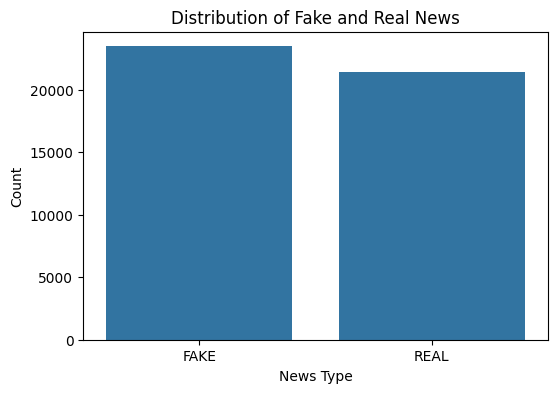

In [27]:
plt.figure(figsize=(6,4))

sns.countplot(x='label', data=df)

plt.title("Distribution of Fake and Real News")
plt.xlabel("News Type")
plt.ylabel("Count")

plt.show()

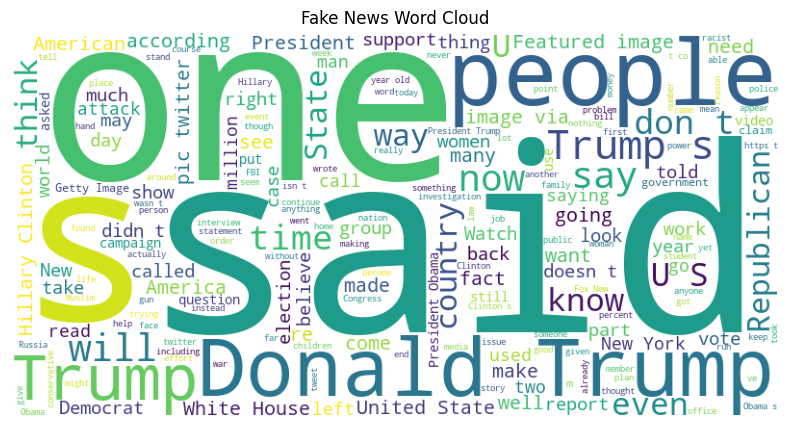

In [28]:
fake_news = ' '.join(df[df['label'] == 'FAKE']['text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(fake_news)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Fake News Word Cloud")

plt.show()

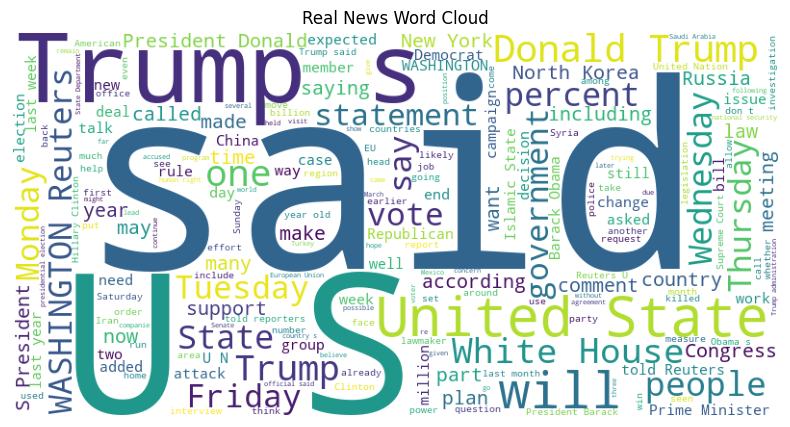

In [29]:
real_news = ' '.join(df[df['label'] == 'REAL']['text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(real_news)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Real News Word Cloud")

plt.show()

In [31]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\\S+', '', text)
    
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    
    # Split words
    words = text.split()
    
    # Remove stopwords
    words = [word for word in words if word not in stop_words]
    
    # Join words
    return ' '.join(words)

In [32]:
df['clean_text'] = df['text'].apply(clean_text)

In [33]:
df[['text', 'clean_text']].head()

,text,clean_text
0,"21st Century Wire says Ben Stein, reputable pr...",st century wire says ben stein reputable profe...
1,WASHINGTON (Reuters) - U.S. President Donald T...,washington reuters u president donald trump re...
2,(Reuters) - Puerto Rico Governor Ricardo Rosse...,reuters puerto rico governor ricardo rossello ...
3,"On Monday, Donald Trump once again embarrassed...",monday donald trump embarrassed country accide...
4,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",glasgow scotland reuters u presidential candid...


In [34]:
X = df['clean_text']

y = df['label']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_df=0.7
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

In [37]:
pac = PassiveAggressiveClassifier(max_iter=50)

pac.fit(X_train_tfidf, y_train)

y_pred_pac = pac.predict(X_test_tfidf)

In [40]:
pac_accuracy = accuracy_score(y_test, y_pred_pac)

print("Passive Aggressive Accuracy:", pac_accuracy*100)

Passive Aggressive Accuracy: 99.2761692650334


In [41]:
print(classification_report(y_test, y_pred_pac))

              precision    recall  f1-score   support

        FAKE       0.99      0.99      0.99      4710
        REAL       0.99      0.99      0.99      4270

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



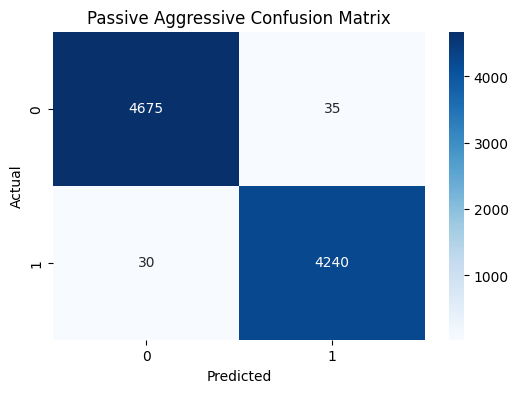

In [42]:
cm = confusion_matrix(y_test, y_pred_pac)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Passive Aggressive Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [43]:
lr = LogisticRegression()

lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)

In [45]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy*100)

Logistic Regression Accuracy: 98.28507795100224


In [46]:
nb = MultinomialNB()

nb.fit(X_train_tfidf, y_train)

y_pred_nb = nb.predict(X_test_tfidf)

In [48]:
nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_accuracy*100)

Naive Bayes Accuracy: 93.14031180400892


In [49]:
models = pd.DataFrame({
    'Model': [
        'Passive Aggressive',
        'Logistic Regression',
        'Naive Bayes'
    ],
    
    'Accuracy': [
        pac_accuracy,
        lr_accuracy,
        nb_accuracy
    ]
})

models

,Model,Accuracy
0,Passive Aggressive,0.992762
1,Logistic Regression,0.982851
2,Naive Bayes,0.931403


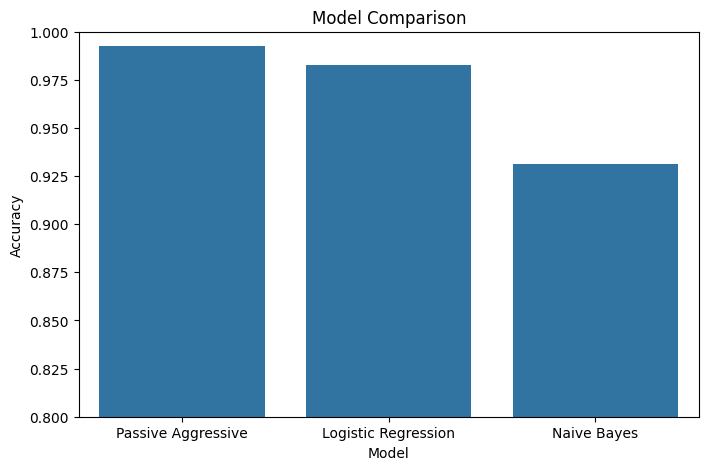

In [50]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=models
)

plt.title("Model Comparison")

plt.ylim(0.8, 1.0)

plt.show()

In [51]:
import pickle

pickle.dump(pac, open('fake_news_model.pkl', 'wb'))

pickle.dump(vectorizer, open('tfidf_vectorizer.pkl', 'wb'))

In [52]:
def predict_news(news):
    
    # Clean text
    cleaned_news = clean_text(news)
    
    # Vectorize
    vectorized_news = vectorizer.transform([cleaned_news])
    
    # Predict
    prediction = pac.predict(vectorized_news)
    
    return prediction[0]

In [53]:
sample_news = """
The government has announced a new policy 
to improve the education system across the country.
"""

prediction = predict_news(sample_news)

print("Prediction:", prediction)

Prediction: FAKE
